# Rosenbrock Optimization (Unconstrained and Constrained)
### MECH 559 - Systems Optimization

This notebook demonstrates how to solve:
1. the unconstrained Rosenbrock problem, and
2. a constrained Rosenbrock variant with inequality constraints.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

---
## 1. Define the Rosenbrock Objective

For $x = [x_1, x_2]^\top$, the 2D Rosenbrock function is:
$$f(x_1, x_2) = (1 - x_1)^2 + 100(x_2 - x_1^2)^2$$

Its global minimum is at $(x_1^*, x_2^*) = (1, 1)$ with $f^* = 0$.

In [29]:
def rosenbrock(x):
    x1, x2 = x
    return (1 - x1)**2 + 100 * (x2 - x1**2)**2

def rosenbrock_grad(x):
    x1, x2 = x
    dfdx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)
    dfdx2 = 200 * (x2 - x1**2)
    return np.array([dfdx1, dfdx2])

x0 = np.array([-1.2, 1.0])  # common initial guess
x1b = np.array([-2, 2])  # example lower bounds for x1 and x2
x2b = np.array([-2, 2])    # example upper bounds for x1 and x2

---
## 2. Unconstrained Optimization

We solve:
$$\min_x f(x_1, x_2)$$
using `scipy.optimize.minimize` with BFGS.

In [30]:
res_unc = minimize(
    fun=rosenbrock,
    x0=x0,
    bounds=[(x1b), (x2b)],
    options={'disp': False}
)

print('Unconstrained Rosenbrock (BFGS)')
print(f'  success: {res_unc.success}')
print(f'  message: {res_unc.message}')
print(f'  x*     : {res_unc.x}')
print(f'  f(x*)  : {res_unc.fun:.6e}')
print(f'  niter  : {res_unc.nit}')

Unconstrained Rosenbrock (BFGS)
  success: True
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  x*     : [0.99999846 0.99999682]
  f(x*)  : 3.300873e-12
  niter  : 33


C:\Users\vhddp6\AppData\Local\Temp\ipykernel_26384\163173450.py:1: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_unc = minimize(


---
## 3. Constrained Rosenbrock Optimization

Now solve a constrained variant:
$$\min_x f(x_1, x_2)$$
subject to
$$g_1(x) = 1 - x_1 - x_2 \leq 0$$
$$g_2(x) = (x_1^2 + x_2^2) - 1.5 \leq 0$$

The first constraint is linear and the second keeps the solution inside a circle of radius $\sqrt{1.5}$.

In [31]:
def g1_leq(x):
    return 1.0 - x[0] - x[1]             # <= 0

def g2_leq(x):
    return (x[0]**2 + x[1]**2) - 1.5     # <= 0

# scipy SLSQP expects ineq constraints in the form c(x) >= 0,
# so we pass c(x) = -g(x) for each g(x) <= 0 constraint.
constraints = [
    {'type': 'ineq', 'fun': lambda x: -g1_leq(x)},
    {'type': 'ineq', 'fun': lambda x: -g2_leq(x)},
]

# Bounds are optional here but help keep the search region readable
bounds = [(-1.5, 1.5), (-0.5, 1.8)]

res_con = minimize(
    fun=rosenbrock,
    x0=np.array([-0.8, 1.2]),
    jac=rosenbrock_grad,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-10, 'maxiter': 500, 'disp': False}
)

print('Constrained Rosenbrock (SLSQP)')
print(f'  success: {res_con.success}')
print(f'  message: {res_con.message}')
print(f'  x*     : {res_con.x}')
print(f'  f(x*)  : {res_con.fun:.6e}')
print(f'  niter  : {res_con.nit}')

g1 = g1_leq(res_con.x)
g2 = g2_leq(res_con.x)
print('Constraint check (should be <= 0):')
print(f'  g1 = 1 - x1 - x2         = {g1:.6e}')
print(f'  g2 = x1^2 + x2^2 - 1.5   = {g2:.6e}')

Constrained Rosenbrock (SLSQP)
  success: True
  message: Optimization terminated successfully
  x*     : [0.90723396 0.82275545]
  f(x*)  : 8.615651e-03
  niter  : 20
Constraint check (should be <= 0):
  g1 = 1 - x1 - x2         = -7.299894e-01
  g2 = x1^2 + x2^2 - 1.5   = 8.335554e-12


---
## 4. Second Constrained Problem (Two Linear Constraints)

Define a second constrained Rosenbrock problem with two linear inequalities:
$$\min_x f(x_1, x_2)$$
subject to
$$g_{L1}(x) = n_1^\top(x - x_t) \leq 0$$
$$g_{L2}(x) = s\,n_2^\top(x - x_t) \leq 0$$

where $n_1$ and $n_2$ are line normals and $x_t$ is the line intersection point.


Tangent-constraint Rosenbrock (SLSQP)
  success: True
  message: Optimization terminated successfully
  x_tan  : [0.90723396 0.82275545]
  x*     : [0.90723396 0.82275545]
  f(x*)  : 8.615651e-03
Constraint check (should be <= 0, both near 0):
  gL1 = n1^T(x - x_t)   = 0.000000e+00
  gL2 = s n2^T(x - x_t) = 0.000000e+00
  ||x* - x_tan||               = 0.000000e+00


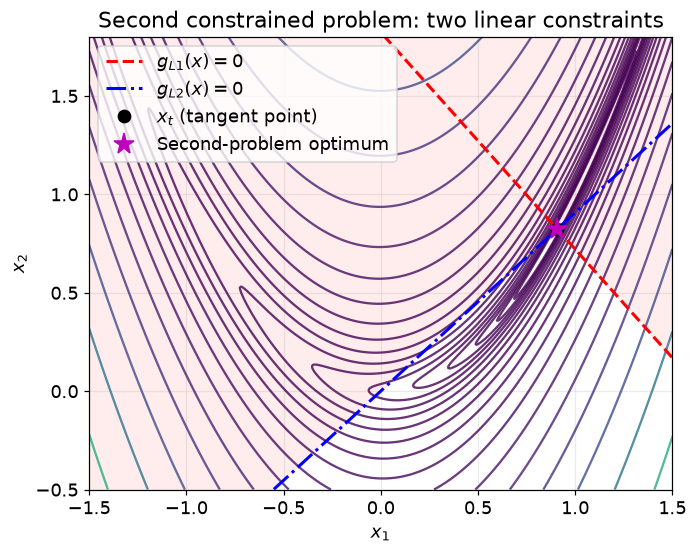

In [32]:
r2 = 1.5
r = np.sqrt(r2)

# Reference point for line intersection (project previous constrained optimum to radius sqrt(1.5))
x_tan = res_con.x.copy()
x_tan = x_tan * (r / np.linalg.norm(x_tan))

# First line normal (radial direction), second line normal (perpendicular direction)
n1 = x_tan / np.linalg.norm(x_tan)
n2 = np.array([-n1[1], n1[0]])

def gL1_leq(x):
    return np.dot(n1, x - x_tan)      # <= 0

# Pick sign so that point (1,1) is on the infeasible side of the second linear constraint
x_ref = np.array([1.0, 1.0])
s = np.sign(np.dot(n2, x_ref - x_tan))
if s == 0:
    s = 1.0

def gL2_leq(x):
    return s * np.dot(n2, x - x_tan)  # <= 0

constraints_tan = [
    {'type': 'ineq', 'fun': lambda x: -gL1_leq(x)},
    {'type': 'ineq', 'fun': lambda x: -gL2_leq(x)},
]

res_tan = minimize(
    fun=rosenbrock,
    x0=x_tan + np.array([0.05, -0.03]),
    jac=rosenbrock_grad,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_tan,
    options={'ftol': 1e-12, 'maxiter': 500, 'disp': False}
)

print('Tangent-constraint Rosenbrock (SLSQP)')
print(f'  success: {res_tan.success}')
print(f'  message: {res_tan.message}')
print(f'  x_tan  : {x_tan}')
print(f'  x*     : {res_tan.x}')
print(f'  f(x*)  : {res_tan.fun:.6e}')

g_line1 = gL1_leq(res_tan.x)
g_line2 = gL2_leq(res_tan.x)
print('Constraint check (should be <= 0, both near 0):')
print(f'  gL1 = n1^T(x - x_t)   = {g_line1:.6e}')
print(f'  gL2 = s n2^T(x - x_t) = {g_line2:.6e}')
print(f'  ||x* - x_tan||               = {np.linalg.norm(res_tan.x - x_tan):.6e}')

# Geometry plot for the two-linear-constraint problem
x1v = np.linspace(-1.5, 1.5, 400)
x2v = np.linspace(-0.5, 1.8, 400)
X1v, X2v = np.meshgrid(x1v, x2v)
Zv = (1 - X1v)**2 + 100 * (X2v - X1v**2)**2

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.contour(X1v, X2v, Zv, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.8)

# L1 boundary: n1^T(x - x_t) = 0
if abs(n1[1]) > 1e-12:
    y_l1 = x_tan[1] - (n1[0] / n1[1]) * (x1v - x_tan[0])
    ax.plot(x1v, y_l1, 'r--', lw=2, label='$g_{L1}(x)=0$')
else:
    x_l1 = np.full_like(x1v, x_tan[0])
    ax.plot(x_l1, x1v, 'r--', lw=2, label='$g_{L1}(x)=0$')

# L2 boundary: s*n2^T(x - x_t) = 0
if abs(n2[1]) > 1e-12:
    y_l2 = x_tan[1] - (n2[0] / n2[1]) * (x1v - x_tan[0])
    ax.plot(x1v, y_l2, 'b-.', lw=2, label='$g_{L2}(x)=0$')
else:
    x_l2 = np.full_like(x1v, x_tan[0])
    ax.plot(x_l2, x1v, 'b-.', lw=2, label='$g_{L2}(x)=0$')

# Shade infeasible region
x1c = np.linspace(-1.5, 1.5, 180)
x2c = np.linspace(-0.5, 1.8, 180)
X1c, X2c = np.meshgrid(x1c, x2c)
GL1 = n1[0] * (X1c - x_tan[0]) + n1[1] * (X2c - x_tan[1])
GL2 = s * (n2[0] * (X1c - x_tan[0]) + n2[1] * (X2c - x_tan[1]))
feas2 = (GL1 <= 0) & (GL2 <= 0)
infeas2 = ~feas2
ax.contourf(X1c, X2c, infeas2.astype(float), levels=[0.5, 1.5], colors=['#ffd6d6'], alpha=0.45)

ax.plot(x_tan[0], x_tan[1], 'ko', ms=8, label='$x_t$ (tangent point)')
ax.plot(res_tan.x[0], res_tan.x[1], 'm*', ms=14, label='Second-problem optimum')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-0.5, 1.8])
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Second constrained problem: two linear constraints')
ax.grid(True, alpha=0.25)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. Visualization

The plots below show objective contours and the two optima.

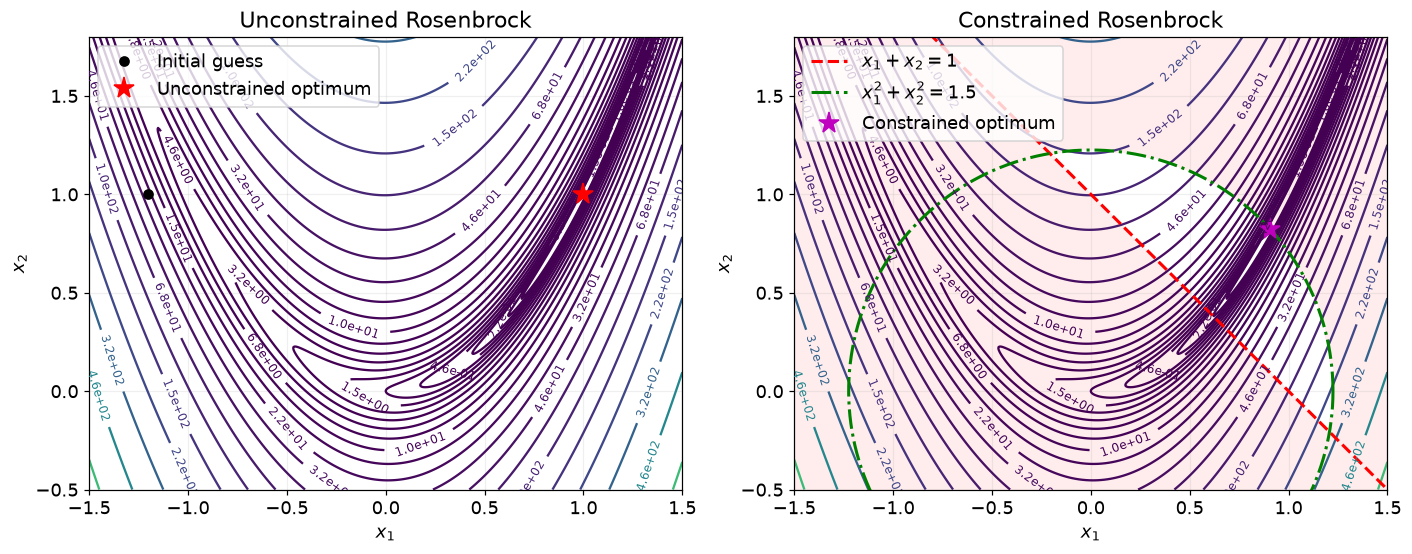

In [33]:
x1 = np.linspace(-1.5, 1.5, 500)
x2 = np.linspace(-0.5, 1.8, 500)
X1, X2 = np.meshgrid(x1, x2)
Z = (1 - X1)**2 + 100 * (X2 - X1**2)**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
levels = np.logspace(-1, 3, 25)

# Left: unconstrained
ax = axes[0]
c1 = ax.contour(X1, X2, Z, levels=levels, cmap='viridis')
ax.clabel(c1, inline=True, fontsize=8, fmt='%.1e')
ax.plot(x0[0], x0[1], 'ko', label='Initial guess')
ax.plot(res_unc.x[0], res_unc.x[1], 'r*', ms=14, label='Unconstrained optimum')
ax.set_title('Unconstrained Rosenbrock')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.grid(True, alpha=0.2)
ax.legend(loc='upper left')

# Right: constrained
ax = axes[1]
c2 = ax.contour(X1, X2, Z, levels=levels, cmap='viridis')
ax.clabel(c2, inline=True, fontsize=8, fmt='%.1e')

# Feasible set boundaries
line_x = np.linspace(-1.5, 1.5, 400)
line_y = 1.0 - line_x
theta = np.linspace(0, 2*np.pi, 400)
cx = np.sqrt(1.5) * np.cos(theta)
cy = np.sqrt(1.5) * np.sin(theta)

ax.plot(line_x, line_y, 'r--', lw=2, label='$x_1 + x_2 = 1$')
ax.plot(cx, cy, 'g-.', lw=2, label='$x_1^2 + x_2^2 = 1.5$')

# Shade infeasible points on a coarse grid
x1c = np.linspace(-1.5, 1.5, 160)
x2c = np.linspace(-0.5, 1.8, 160)
X1c, X2c = np.meshgrid(x1c, x2c)
G1 = 1.0 - X1c - X2c
G2 = (X1c**2 + X2c**2) - 1.5
feas = (G1 <= 0) & (G2 <= 0)
infeas = ~feas
ax.contourf(X1c, X2c, infeas.astype(float), levels=[0.5, 1.5], colors=['#ffd6d6'], alpha=0.45)

ax.plot(res_con.x[0], res_con.x[1], 'm*', ms=14, label='Constrained optimum')
ax.set_title('Constrained Rosenbrock')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-0.5, 1.8])
ax.grid(True, alpha=0.2)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 6. Comparison Summary

- Unconstrained problem converges to $(1,1)$ with objective value near zero.
- Constrained problem may move away from $(1,1)$ if the feasible set excludes that point or forces trade-offs.
- SLSQP is a practical choice for smooth nonlinear constraints.